### Factor level visualization

In [6]:
from scenario_generator import *
import yaml
import matplotlib.pyplot as plt
_exp = "temporal_cond"

In [7]:
PREFIX = f"model/{_exp}"
with open(f"{PREFIX}/cfg.yaml") as f:
    _cfg = yaml.safe_load(f)
diffusion_temporal = np.load(f"{PREFIX}/samples/path_cond_markov1_500x22.npy")

In [8]:
diffusion_temporal.shape

(500, 7, 22)

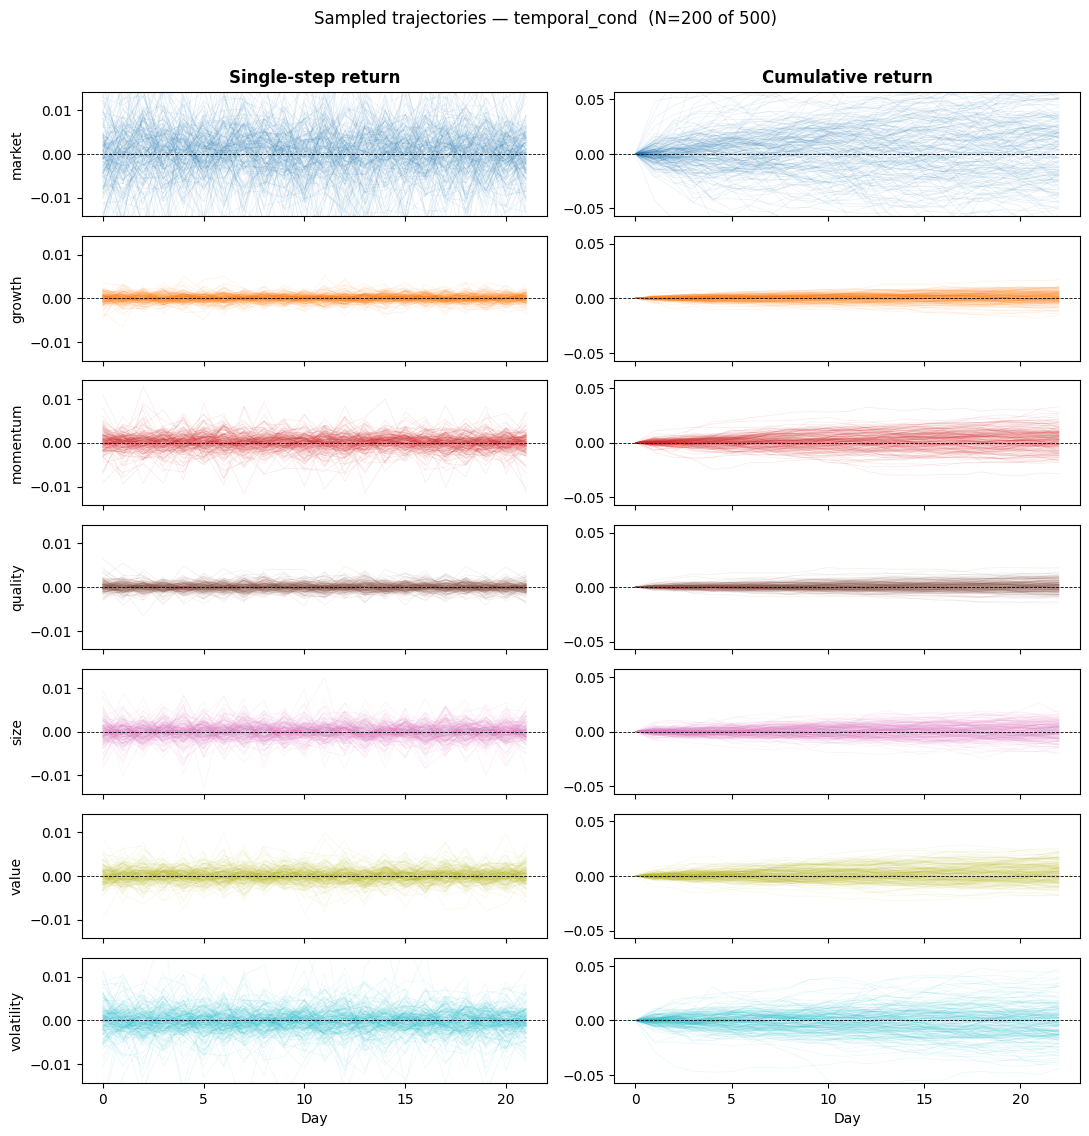

In [9]:
factors = _cfg["factors"]
F = len(factors)
N_paths, _, D = diffusion_temporal.shape

rng     = np.random.default_rng(42)
idx     = rng.choice(N_paths, size=min(200, N_paths), replace=False)
sample  = diffusion_temporal[idx]                                # (N, F, D)
cum     = np.concatenate([np.zeros((sample.shape[0], F, 1)),
                          np.cumsum(sample, axis=2)], axis=2)    # (N, F, D+1)

days_step = np.arange(D)
days_cum  = np.arange(D + 1)

step_ylim = float(np.quantile(np.abs(sample), 0.99))
cum_ylim  = float(np.quantile(np.abs(cum),    0.99))

fig, axes = plt.subplots(F, 2, figsize=(11, 1.6 * F), sharex="col")
colors = plt.cm.tab10(np.linspace(0, 1, F))

for r, name in enumerate(factors):
    ax_s, ax_c = axes[r, 0], axes[r, 1]
    for p in range(sample.shape[0]):
        ax_s.plot(days_step, sample[p, r], color=colors[r], alpha=0.1, lw=0.5)
        ax_c.plot(days_cum,  cum[p, r],    color=colors[r], alpha=0.1, lw=0.5)
    for ax in (ax_s, ax_c):
        ax.axhline(0, color="k", ls="--", lw=0.6)
    ax_s.set_ylim(-step_ylim, step_ylim)
    ax_c.set_ylim(-cum_ylim,  cum_ylim)
    ax_s.set_ylabel(name, fontsize=10)
    if r == 0:
        ax_s.set_title("Single-step return", fontweight="bold")
        ax_c.set_title("Cumulative return",  fontweight="bold")
    if r == F - 1:
        ax_s.set_xlabel("Day")
        ax_c.set_xlabel("Day")

fig.suptitle(f"Sampled trajectories — {_exp}  (N={sample.shape[0]} of {N_paths})", y=1.01)
fig.tight_layout()
plt.show()

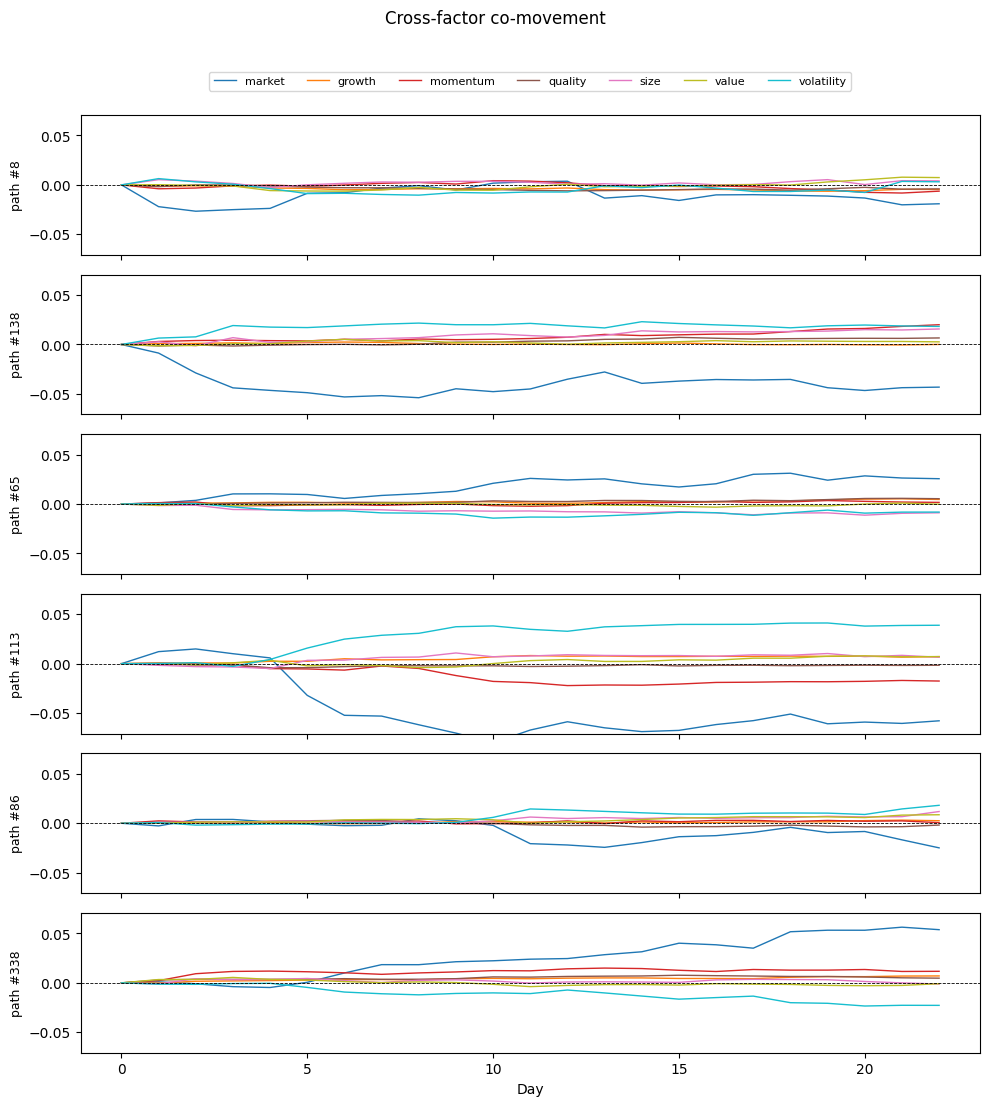

In [11]:
K  = 6
path_ix = rng.choice(N_paths, size=K, replace=False)
cum_all = np.concatenate([np.zeros((N_paths, F, 1)),
                          np.cumsum(diffusion_temporal, axis=2)], axis=2)  # (N, F, D+1)
ylim_co = float(np.quantile(np.abs(cum_all), 0.995))
fig, axes = plt.subplots(K, 1, figsize=(10, 1.8 * K), sharex=True, sharey=True)
for ax, pi in zip(axes, path_ix):
    for f, name in enumerate(factors):
        ax.plot(days_cum, cum_all[pi, f], color=colors[f], lw=1.0, label=name)
    ax.axhline(0, color="k", ls="--", lw=0.6)
    ax.set_ylim(-ylim_co, ylim_co)
    ax.set_ylabel(f"path #{pi}", fontsize=9)
axes[0].legend(ncol=F, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.35))
axes[-1].set_xlabel("Day")
fig.suptitle(f"Cross-factor co-movement", y=1.02)
fig.tight_layout()
plt.show()

### Stock level evaluation